# TASK #1: UNDERSTAND THE PROBLEM STATEMENT AND BUSINESS CASE

In [1]:
pip install nbconvert[webpdf]


Note: you may need to restart the kernel to use updated packages.


Google and Aravind Eye Hospital work: https://venturebeat.com/2019/02/25/google-works-with-aravind-eye-hospital-to-deploy-ai-that-can-detect-eye-disease/

Data Source: https://www.kaggle.com/c/diabetic-retinopathy-detection

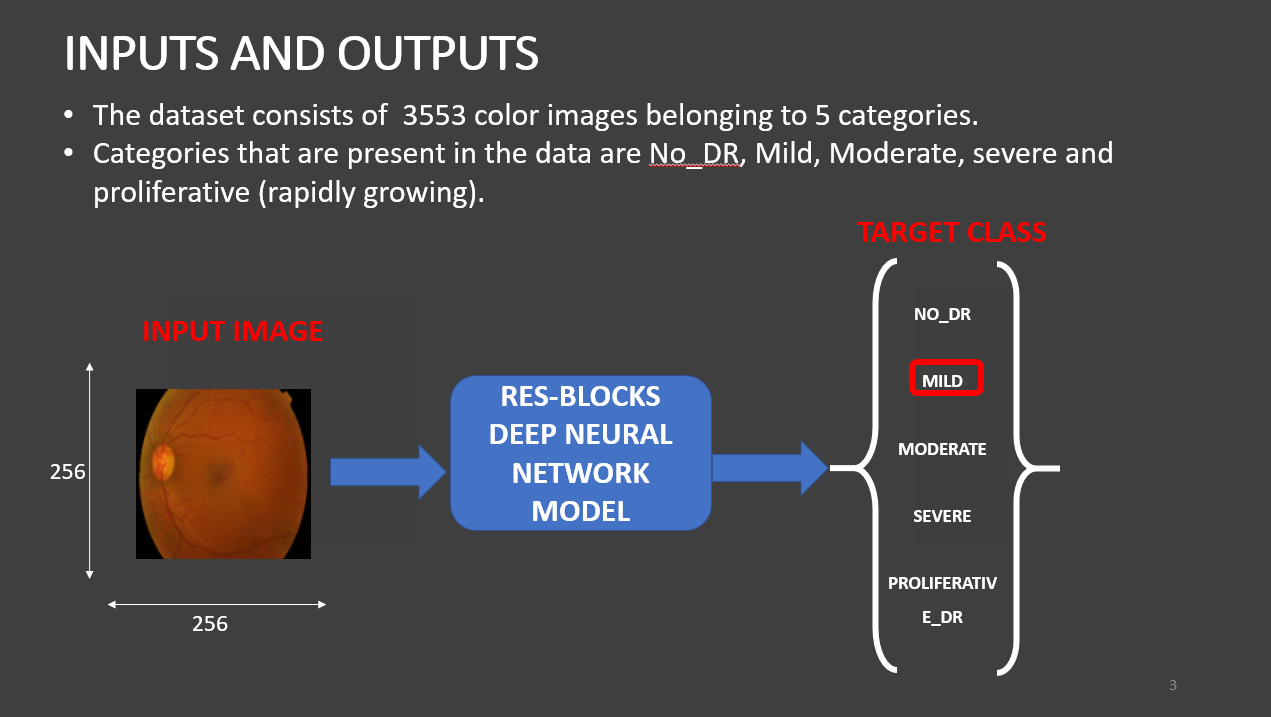

# TASK #2: IMPORT LIBRARIES/DATASETS

In [2]:
pip install jupyterthemes


Note: you may need to restart the kernel to use updated packages.


In [3]:
from jupyterthemes import jtplot
jtplot.style(theme='monokai', context='notebook', ticks=True, grid=False)

# setting the style of the notebook to be monokai theme  
# this line of code is important to ensure that we are able to see the x and y axes clearly
# If you don't run this code line, you will notice that the xlabel and ylabel on any plot is black on black and it will be hard to see them. 

In [4]:
# Import the necessary packages

import pandas as pd
print(pd.__version__)
import numpy as np
import tensorflow as tf
from tensorflow import keras
import os
import matplotlib.pyplot as plt
import PIL
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from IPython.display import display
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler



2.2.3


In [5]:

# Check if the file exists
if os.path.isfile('D:\\DL PROJECT VSCODE\\datasets\\train.csv'):
    print("File exists")
else:
    print("File does not exist")


File exists


In [6]:
with open("D:\\DL PROJECT VSCODE\\datasets\\train.csv", 'r') as file:
    for line in file:
        print(line.strip())  # Printing each line in the file



id_code,diagnosis
000c1434d8d7,2
001639a390f0,4
0024cdab0c1e,1
002c21358ce6,0
005b95c28852,0
0083ee8054ee,4
0097f532ac9f,0
00a8624548a9,2
00b74780d31d,2
00cb6555d108,1
00cc2b75cddd,0
00e4ddff966a,2
00f6c1be5a33,0
0104b032c141,3
0124dffecf29,1
0125fbd2e791,0
012a242ac6ff,2
014508ccb9cb,0
0151781fe50b,0
0161338f53cc,2
0180bfa26c0b,2
0182152c50de,0
01b3aed3ed4c,1
01c7808d901d,2
01d9477b1171,0
01eb826f6467,2
01f7bb8be950,0
0212dd31f623,0
022f820027b8,0
0231642cf1c2,0
0232dfea7547,0
02358b47ea89,0
0243404e8a00,4
025a169a0bb0,2
02685f13cefd,4
026dcd9af143,2
02cd34a85b24,0
02da652c74b8,0
02dda30d3acf,4
0304bedad8fe,0
0318598cfd16,4
032d7b0b4bf6,2
033f2b43de6d,2
034cb07a550f,4
03676c71ed1b,2
0369f3efe69b,1
03747397839f,2
03a7f4a5786f,4
03b373718013,0
03c85870824c,3
03e25101e8e8,1
03fd50da928d,2
03ff7d159f10,2
0415fc68b176,2
041f09eec1e8,2
0423237770a7,0
042470a92154,3
04579e31e4be,0
04a6fc58dabc,2
04ac765f91a1,1
04aef84a2cc1,0
04d029cfb612,2
04efb1a284cc,0
050bb1eafa76,0
05113073b268,0
05195a3

In [7]:


# Define the folder paths
folders = { 
    'Mild': r'D:\DL PROJECT VSCODE\datasets\Mild',
    'Moderate': r'D:\DL PROJECT VSCODE\datasets\Moderate',
    'No_DR': r'D:\DL PROJECT VSCODE\datasets\No_DR',
    'Proliferate_DR': r'D:\DL PROJECT VSCODE\datasets\Proliferate_DR',
    'Severe': r'D:\DL PROJECT VSCODE\datasets\Severe'
}

# Iterate over each folder and process the images
for folder_name, folder_path in folders.items():
    print(f"Processing folder: {folder_name}")
    
    # Check if the folder exists
    if os.path.exists(folder_path):
        # Iterate over all files in the folder
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            
            # Check if it's a file (and not a directory) and if it's an image
            if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
                print(f"Found image file: {filename} in {folder_name}")
    else:
        print(f"Folder {folder_name} does not exist.")


Processing folder: Mild
Found image file: 0024cdab0c1e.png in Mild
Found image file: 00cb6555d108.png in Mild
Found image file: 0124dffecf29.png in Mild
Found image file: 01b3aed3ed4c.png in Mild
Found image file: 0369f3efe69b.png in Mild
Found image file: 03e25101e8e8.png in Mild
Found image file: 04ac765f91a1.png in Mild
Found image file: 059bc89df7f4.png in Mild
Found image file: 05a5183c92d0.png in Mild
Found image file: 0684311afdfc.png in Mild
Found image file: 06b71823f9cd.png in Mild
Found image file: 07929d32b5b3.png in Mild
Found image file: 07a1c7073982.png in Mild
Found image file: 086d41d17da8.png in Mild
Found image file: 09935d72892b.png in Mild
Found image file: 0a3202889f4d.png in Mild
Found image file: 0a61bddab956.png in Mild
Found image file: 0ad7f631dedb.png in Mild
Found image file: 0d310aba6373.png in Mild
Found image file: 0dc031c94225.png in Mild
Found image file: 0dce95217626.png in Mild
Found image file: 0eb52045349f.png in Mild
Found image file: 0f495d87656a

In [8]:
folders = {
    'Mild': 'C:/Users/jay4l/Mild',
    'Moderate': 'C:/Users/jay4l/Desktop/Moderate',  # Adjusted for different folder locations
    'No_DR': 'D:/DataSets/No_DR',  # Another example of adjusting the path
    'Proliferate_DR': 'C:/Users/jay4l/Proliferate_DR',
    'Severe': 'C:/Users/jay4l/Severe'
}


In [9]:
# Check if the 'train/Mild' path exists
mild_path = os.path.join('D:\\DL PROJECT VSCODE\\datasets', 'Mild')

# Check if the Mild directory exists
if os.path.exists(mild_path):
    print(f"The directory {mild_path} exists.")
else:
    print(f"The directory {mild_path} does not exist.")


The directory D:\DL PROJECT VSCODE\datasets\Mild exists.


In [10]:


# Print current working directory
print(os.getcwd())


d:\DL PROJECT VSCODE


In [11]:
os.listdir(os.path.join('D:\\DL PROJECT VSCODE\\datasets'))

['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe', 'train.csv']

In [12]:


# Lists to store image paths and labels
train = []
label = []

# Path to the dataset (replace with your actual dataset path)
dataset_path = r'D:\DL PROJECT VSCODE\datasets'

# os.listdir returns the list of directories in the dataset path, i.e., class names like 'Mild', 'Moderate', etc.
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    # Ensure we are processing directories only (in case there are other files in the dataset folder)
    if os.path.isdir(class_path):
        # List the images inside each class folder
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            train.append(image_path)  # Add image path to the train list
            label.append(class_name)  # Add class name as label

# Print the total number of images in the dataset
print('Number of train images: {}\n'.format(len(train)))



Number of train images: 3662



In [13]:
train

['D:\\DL PROJECT VSCODE\\datasets\\Mild\\0024cdab0c1e.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\00cb6555d108.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\0124dffecf29.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\01b3aed3ed4c.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\0369f3efe69b.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\03e25101e8e8.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\04ac765f91a1.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\059bc89df7f4.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\05a5183c92d0.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\0684311afdfc.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\06b71823f9cd.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\07929d32b5b3.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\07a1c7073982.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\086d41d17da8.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\09935d72892b.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\\0a3202889f4d.png',
 'D:\\DL PROJECT VSCODE\\datasets\\Mild\

In [14]:
label

['Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 'Mild',
 


- Print out the count plot for all classes using Seaborn (External Research is Required)
sns.countplot(label)

<Axes: xlabel='count'>

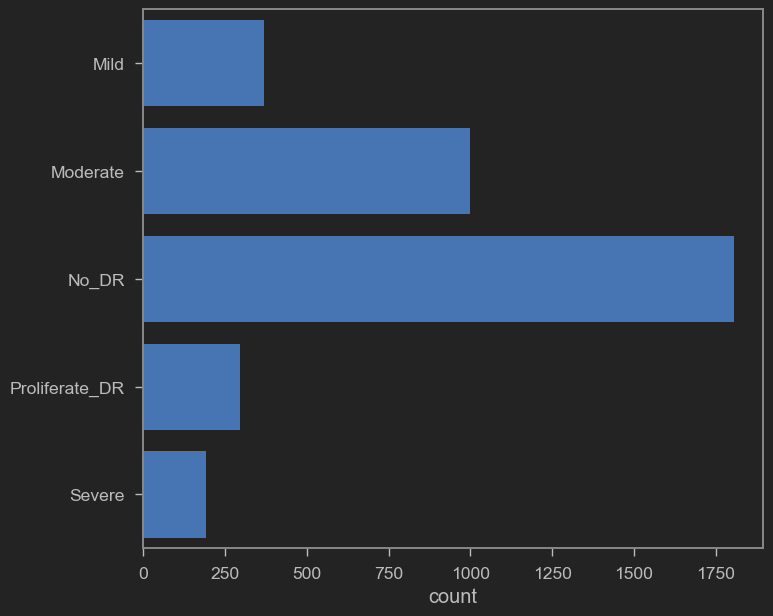

In [15]:
sns.countplot(label)

# TASK #3: PERFORM DATA EXPLORATION AND DATA VISUALIZATION

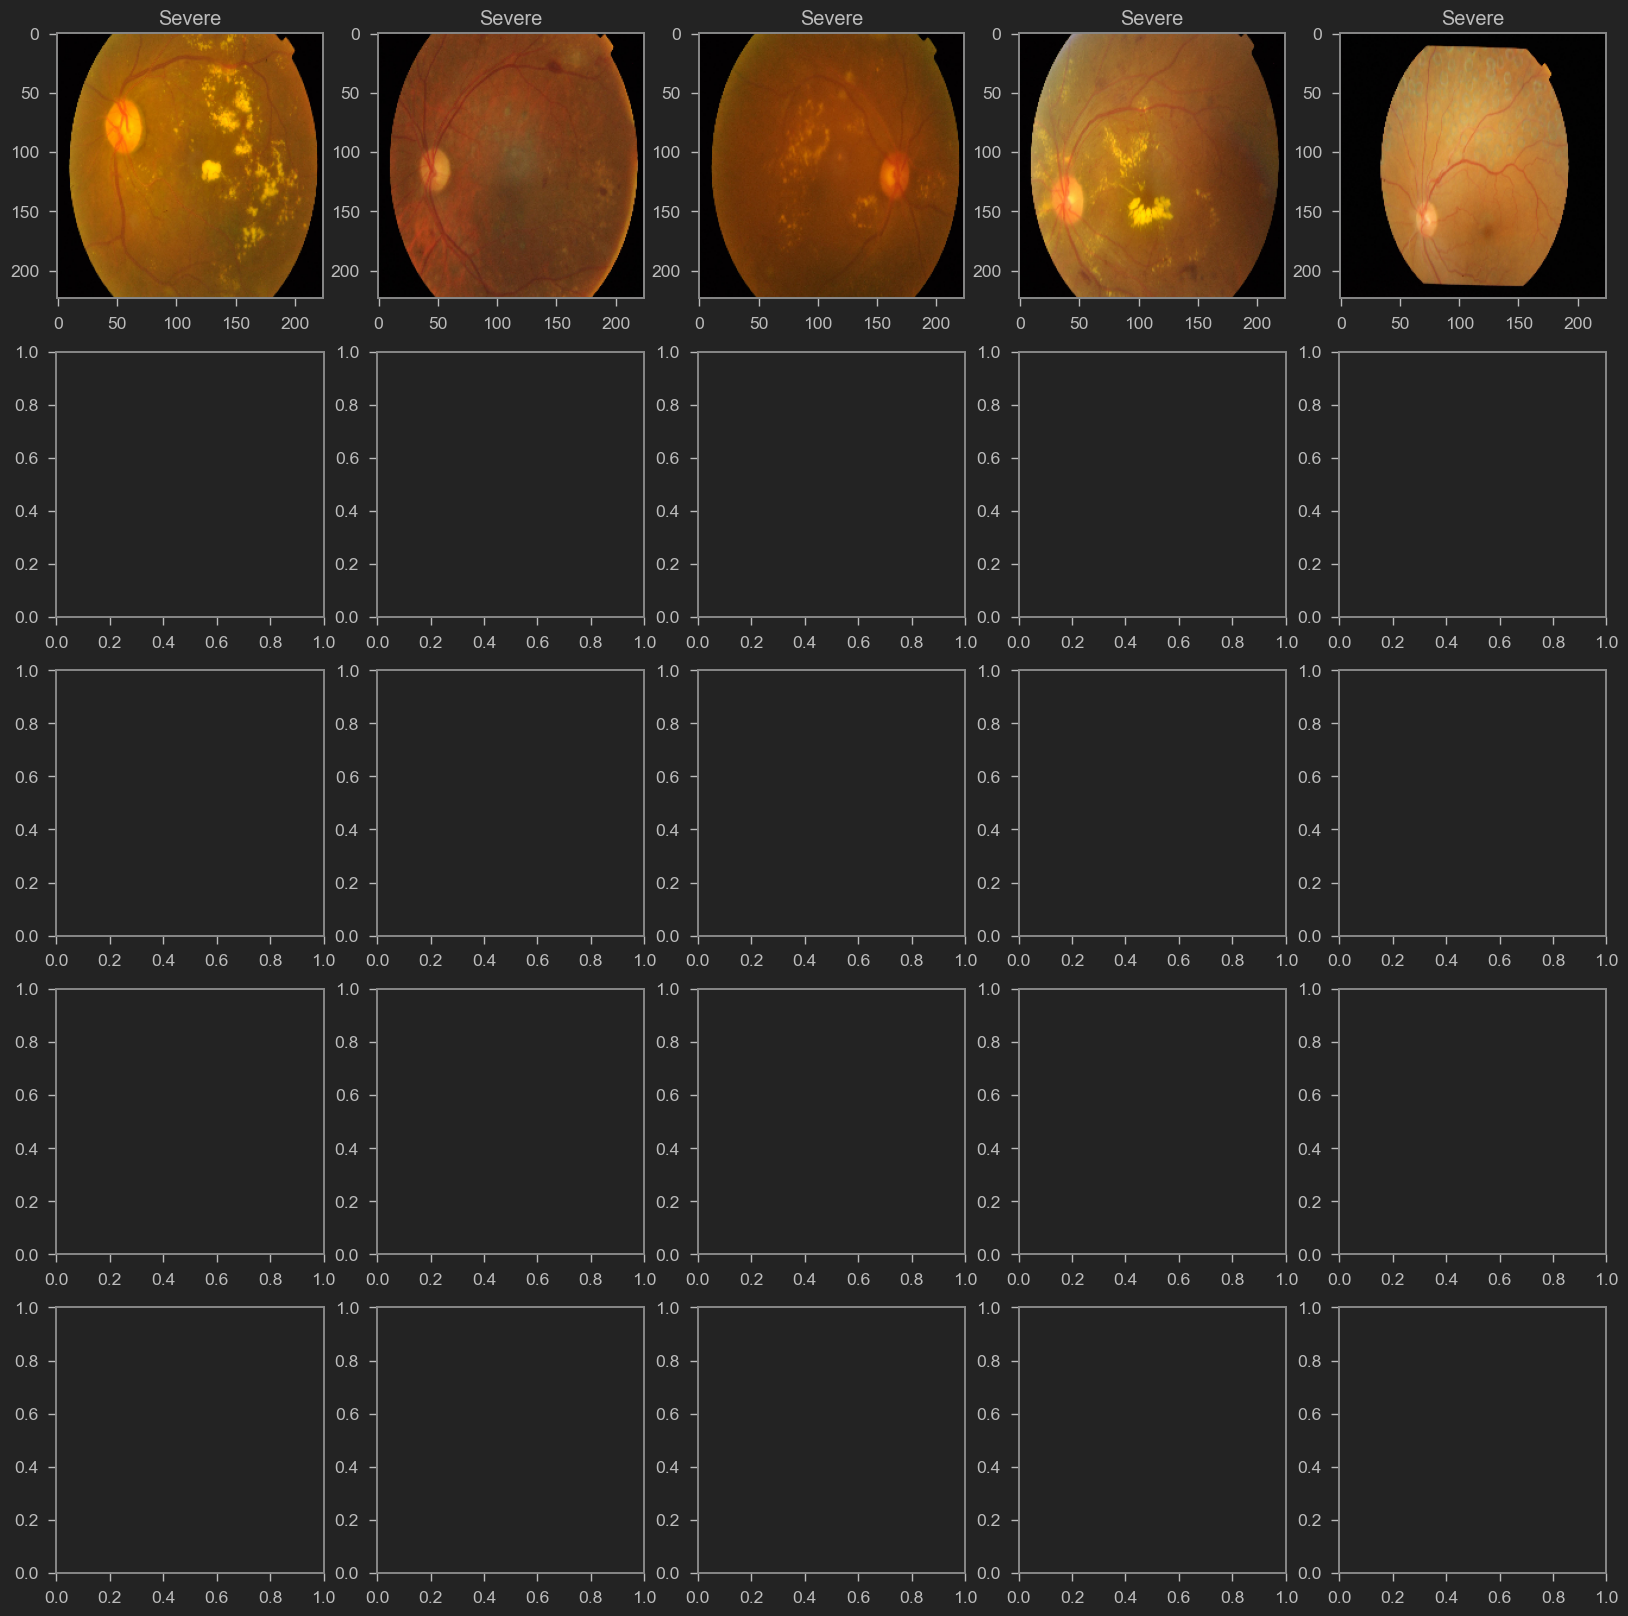

In [16]:

# Define the correct dataset path
dataset_path = r'D:\DL PROJECT VSCODE\datasets'

# Create a subplot of 5x5 (5 images per class for 5 classes)
fig, axs = plt.subplots(5, 5, figsize=(20, 20))
count = 0

# Iterate over each class (Mild, Moderate, etc.)
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    # Skip if it's not a directory (e.g., train.csv)
    if os.path.isdir(class_path):
        # Get the list of images in the class directory
        train_class = os.listdir(class_path)
        
        # Plot 5 images per class
        for j in range(5):
            img_path = os.path.join(class_path, train_class[j])
            img = PIL.Image.open(img_path)
            axs[count][j].title.set_text(class_name)  # Set title as class name
            axs[count][j].imshow(img)  # Display the image


In [17]:
# Check the number of images in each class in the training dataset
No_images_per_class = []
Class_name = []

# Iterate through the contents of the dataset folder
for i in os.listdir(r'D:\DL PROJECT VSCODE\datasets'):
    # Construct the full path and check if it's a directory
    class_path = os.path.join(r'D:\DL PROJECT VSCODE\datasets', i)
    if os.path.isdir(class_path):  # Skip if it's a file (like train.csv)
        train_class = os.listdir(class_path)
        No_images_per_class.append(len(train_class))
        Class_name.append(i)
        print('Number of images in {} = {} \n'.format(i, len(train_class)))


Number of images in Mild = 370 

Number of images in Moderate = 999 

Number of images in No_DR = 1805 

Number of images in Proliferate_DR = 295 

Number of images in Severe = 193 



In [18]:
retina_df = pd.DataFrame({'Image': train,'Labels': label})
retina_df

,Image,Labels
0,D:\DL PROJECT VSCODE\datasets\Mild\0024cdab0c1...,Mild
1,D:\DL PROJECT VSCODE\datasets\Mild\00cb6555d10...,Mild
2,D:\DL PROJECT VSCODE\datasets\Mild\0124dffecf2...,Mild
3,D:\DL PROJECT VSCODE\datasets\Mild\01b3aed3ed4...,Mild
4,D:\DL PROJECT VSCODE\datasets\Mild\0369f3efe69...,Mild
...,...,...
3657,D:\DL PROJECT VSCODE\datasets\Severe\f9156aeff...,Severe
3658,D:\DL PROJECT VSCODE\datasets\Severe\fb61230b9...,Severe
3659,D:\DL PROJECT VSCODE\datasets\Severe\fcc6aa675...,Severe
3660,D:\DL PROJECT VSCODE\datasets\Severe\fda39982a...,Severe


MINI CHALLENGE #2: 
- Plot a pie chart showing the percentage of samples per class. 

# TASK #4: PERFORM DATA AUGMENTATION AND CREATE DATA GENERATOR

In [19]:
# Shuffle the data and split it into training and testing
retina_df = shuffle(retina_df)
train, test = train_test_split(retina_df, test_size = 0.2)

In [20]:
# Create run-time augmentation on training and test dataset
# For training datagenerator, we add normalization, shear angle, zooming range and horizontal flip
train_datagen = ImageDataGenerator(
        rescale = 1./255,
        shear_range = 0.2,
        validation_split = 0.15)

# For test datagenerator, we only normalize the data.
test_datagen = ImageDataGenerator(rescale = 1./255)

In [21]:
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)


In [22]:
# Creating datagenerator for training, validation and test dataset.

train_generator = train_datagen.flow_from_dataframe(
    train,
    directory='./',
    x_col="Image",
    y_col="Labels",
    target_size=(256, 256),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    subset='training')

validation_generator = train_datagen.flow_from_dataframe(
    train,
    directory='./',
    x_col="Image",
    y_col="Labels",
    target_size=(256, 256),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    subset='validation')

test_generator = test_datagen.flow_from_dataframe(
    test,
    directory='./',
    x_col="Image",
    y_col="Labels",
    target_size=(256, 256),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32)

Found 2490 validated image filenames belonging to 5 classes.
Found 439 validated image filenames belonging to 5 classes.
Found 733 validated image filenames belonging to 5 classes.


MINI CHALLENGE #3:

- Experiment with other image augmentation strategies to the training data. Pick at least 1 augmentation strategy. 

HINT: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator




# TASK #5: UNDERSTAND THE THEORY AND INTUITION BEHIND CONVOLUTIONAL NEURAL NETWORKS (CNN) AND RESIDUAL BLOCKS

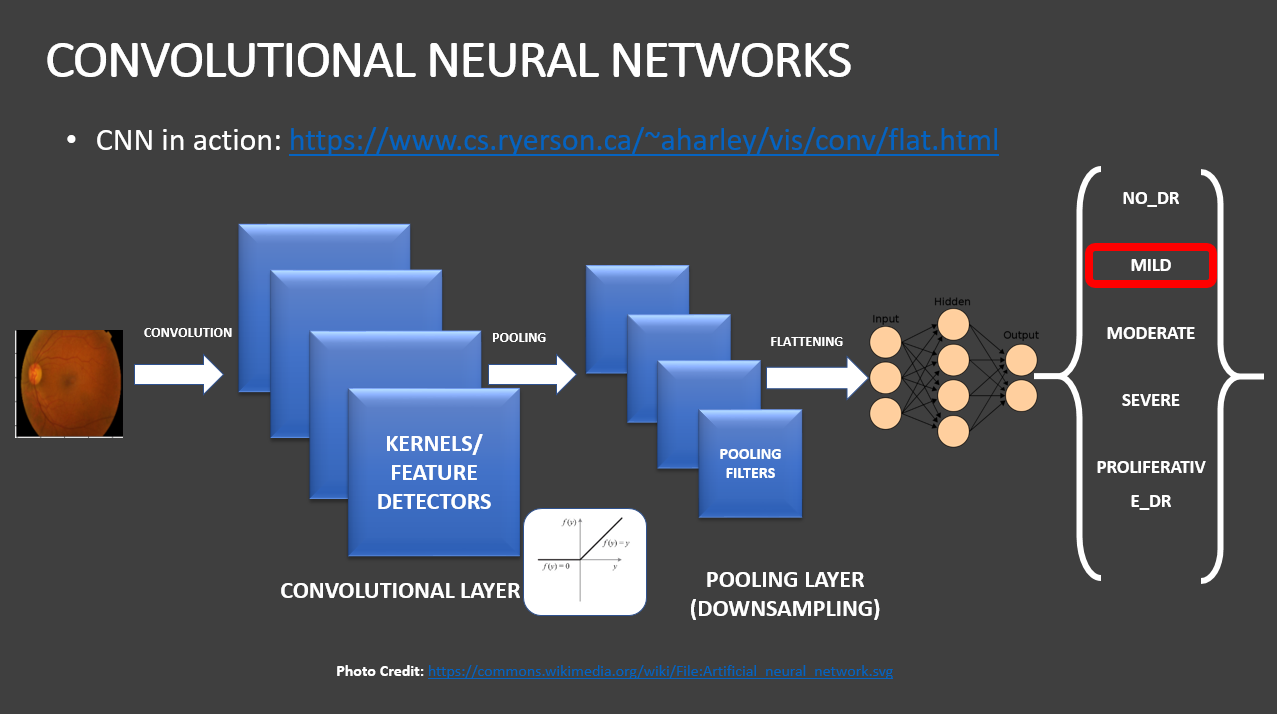

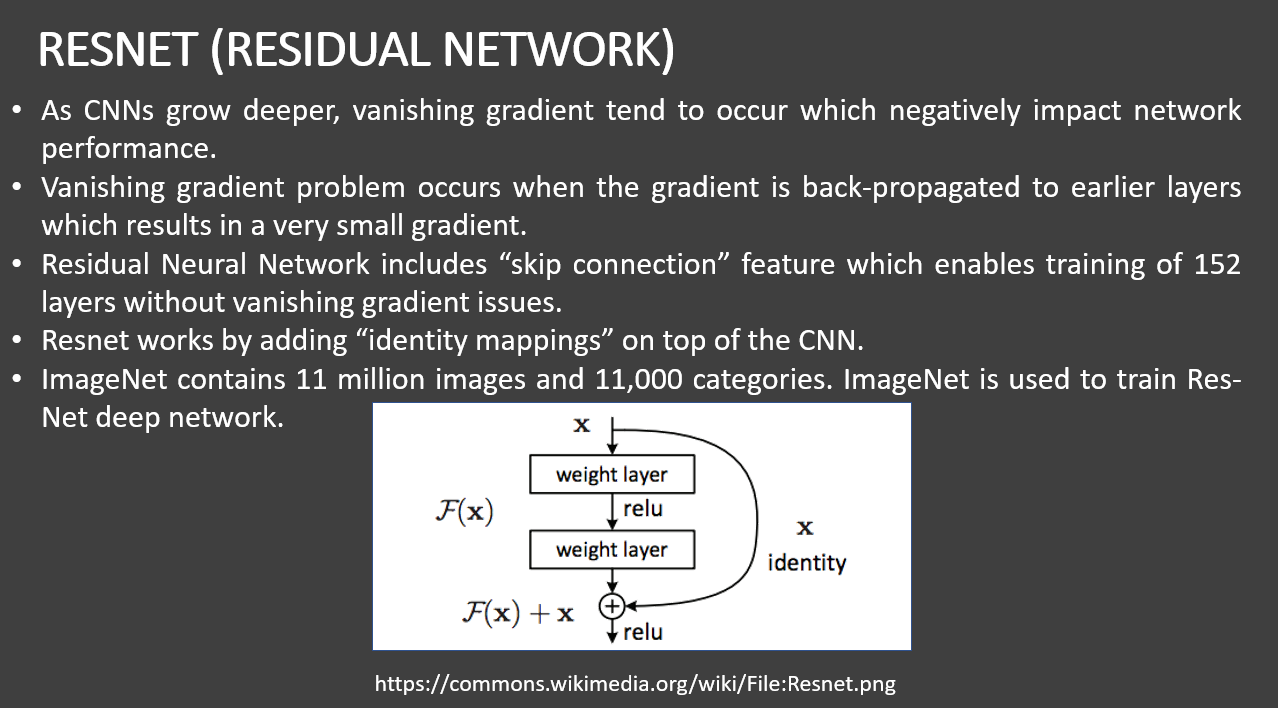

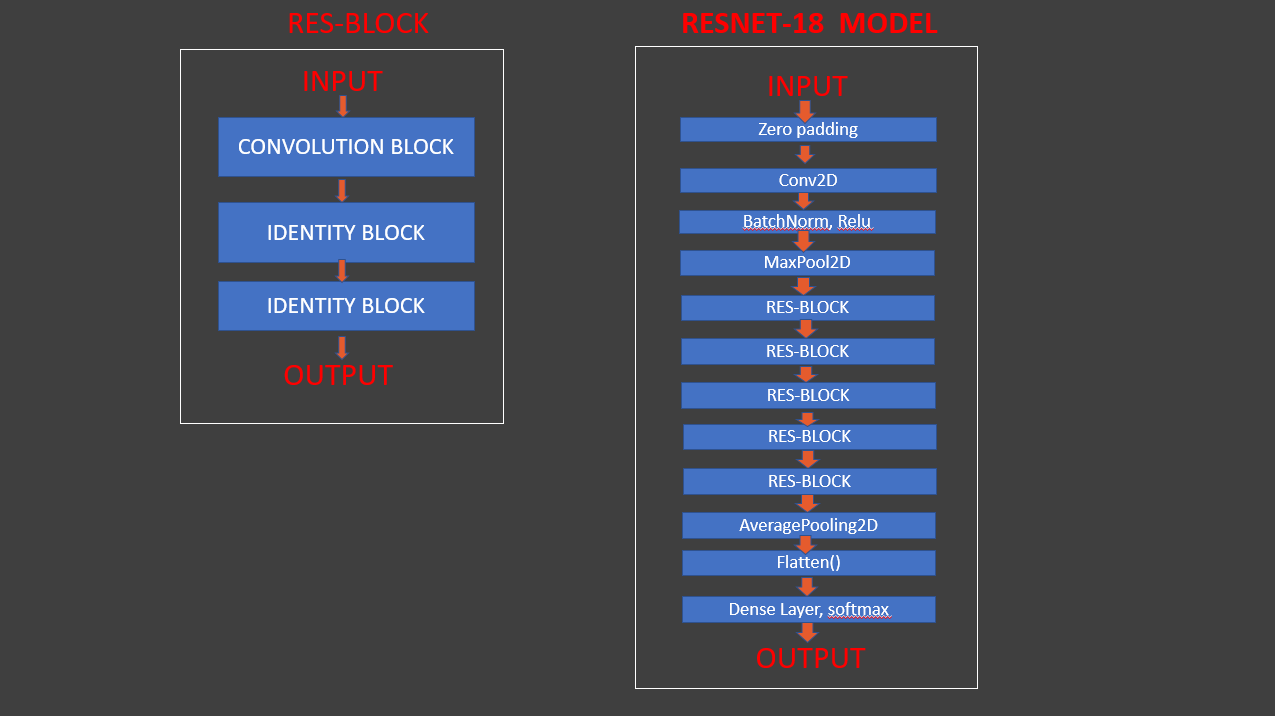

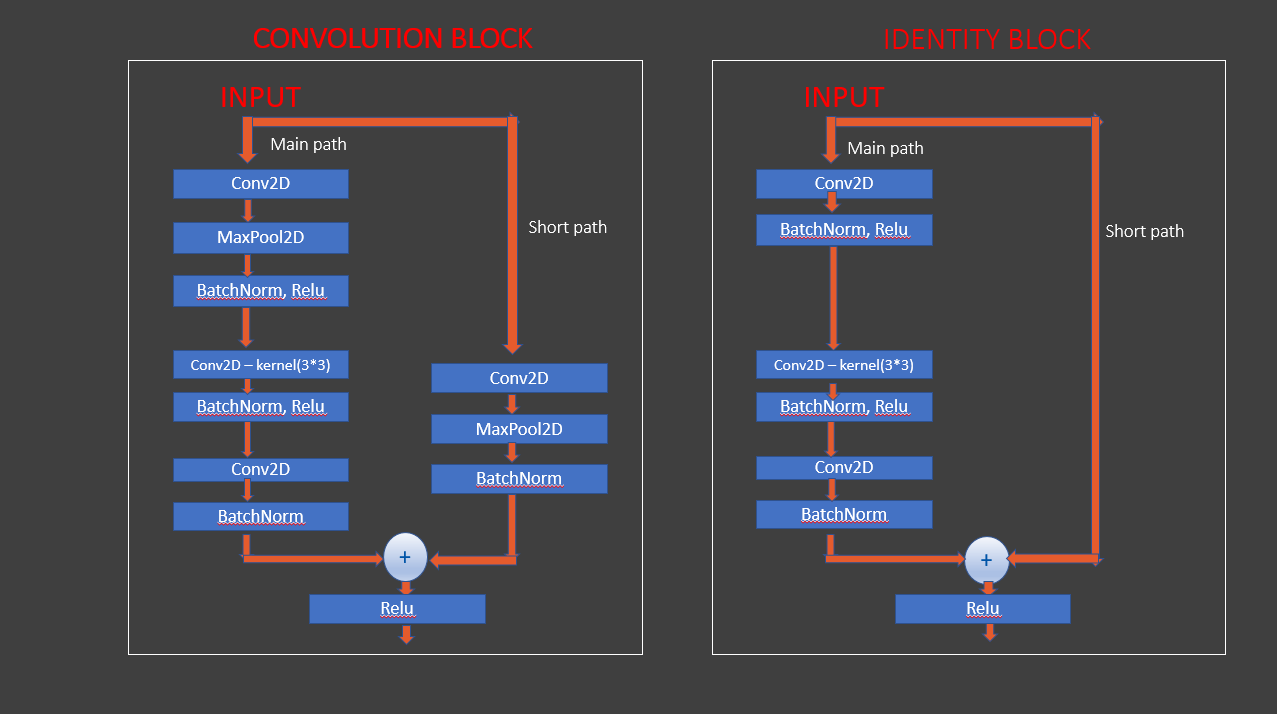

# TASK #6: BUILD RES-BLOCK BASED DEEP LEARNING MODEL

In [23]:
def res_block(X, filter, stage):
  
  # Convolutional_block
  X_copy = X

  f1 , f2, f3 = filter
    
  # Main Path
  X = Conv2D(f1, (1,1),strides = (1,1), name ='res_'+str(stage)+'_conv_a', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = MaxPool2D((2,2))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_a')(X)
  X = Activation('relu')(X) 

  X = Conv2D(f2, kernel_size = (3,3), strides =(1,1), padding = 'same', name ='res_'+str(stage)+'_conv_b', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_b')(X)
  X = Activation('relu')(X) 

  X = Conv2D(f3, kernel_size = (1,1), strides =(1,1),name ='res_'+str(stage)+'_conv_c', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_c')(X)


  # Short path
  X_copy = Conv2D(f3, kernel_size = (1,1), strides =(1,1),name ='res_'+str(stage)+'_conv_copy', kernel_initializer= glorot_uniform(seed = 0))(X_copy)
  X_copy = MaxPool2D((2,2))(X_copy)
  X_copy = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_conv_copy')(X_copy)

  # ADD
  X = Add()([X,X_copy])
  X = Activation('relu')(X)

  # Identity Block 1
  X_copy = X


  # Main Path
  X = Conv2D(f1, (1,1),strides = (1,1), name ='res_'+str(stage)+'_identity_1_a', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_1_a')(X)
  X = Activation('relu')(X) 

  X = Conv2D(f2, kernel_size = (3,3), strides =(1,1), padding = 'same', name ='res_'+str(stage)+'_identity_1_b', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_1_b')(X)
  X = Activation('relu')(X) 

  X = Conv2D(f3, kernel_size = (1,1), strides =(1,1),name ='res_'+str(stage)+'_identity_1_c', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_1_c')(X)

  # ADD
  X = Add()([X,X_copy])
  X = Activation('relu')(X)

  # Identity Block 2
  X_copy = X


  # Main Path
  X = Conv2D(f1, (1,1),strides = (1,1), name ='res_'+str(stage)+'_identity_2_a', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_2_a')(X)
  X = Activation('relu')(X) 

  X = Conv2D(f2, kernel_size = (3,3), strides =(1,1), padding = 'same', name ='res_'+str(stage)+'_identity_2_b', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_2_b')(X)
  X = Activation('relu')(X) 

  X = Conv2D(f3, kernel_size = (1,1), strides =(1,1),name ='res_'+str(stage)+'_identity_2_c', kernel_initializer= glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis =3, name = 'bn_'+str(stage)+'_identity_2_c')(X)

  # ADD
  X = Add()([X,X_copy])
  X = Activation('relu')(X)

  return X

In [24]:

input_shape = (256,256,3)

#Input tensor shape
X_input = Input(input_shape)

#Zero-padding

X = ZeroPadding2D((3,3))(X_input)

# 1 - stage

X = Conv2D(64, (7,7), strides= (2,2), name = 'conv1', kernel_initializer= glorot_uniform(seed = 0))(X)
X = BatchNormalization(axis =3, name = 'bn_conv1')(X)
X = Activation('relu')(X)
X = MaxPooling2D((3,3), strides= (2,2))(X)

# 2- stage

X = res_block(X, filter= [64,64,256], stage= 2)

# 3- stage

X = res_block(X, filter= [128,128,512], stage= 3)

# 4- stage

X = res_block(X, filter= [256,256,1024], stage= 4)

# # 5- stage

# X = res_block(X, filter= [512,512,2048], stage= 5)

#Average Pooling

X = AveragePooling2D((2,2), name = 'Averagea_Pooling')(X)

#Final layer

X = Flatten()(X)
X = Dense(5, activation = 'softmax', name = 'Dense_final', kernel_initializer= glorot_uniform(seed=0))(X)


model = Model( inputs= X_input, outputs = X, name = 'Resnet18')

model.summary()

Model: "Resnet18"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 262, 262, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv1 (Conv2D)                 (None, 128, 128, 64  9472        ['zero_padding2d[0][0]']         
                                )                                                                 
                                                                                           

# TASK #7: COMPILE AND TRAIN DEEP LEARNING MODEL

In [25]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics= ['accuracy'])


In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

import os

# Define paths
train_dir = r'D:\DL PROJECT VSCODE\datasets'

# Create an ImageDataGenerator for data augmentation and validation split
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)  # 20% validation split

# Load training images from the folder, automatically splitting into training and validation sets
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),  # Resize images
    batch_size=32,
    class_mode='categorical',  # For multi-class classification
    subset='training'  # Training data subset
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'  # Validation data subset
)

# Define your model (CNN for image classification)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
earlystopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=15)
checkpointer = ModelCheckpoint(filepath="best_weights.keras", verbose=1, save_best_only=True)

# Train the model using the generators
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[earlystopping, checkpointer]
)


Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Epoch 1/50
91/92 [============================>.] - ETA: 0s - loss: 0.9001 - accuracy: 0.6878
Epoch 1: val_loss improved from inf to 0.74554, saving model to best_weights.keras
92/92 [==============================] - 10s 63ms/step - loss: 0.8971 - accuracy: 0.6888 - val_loss: 0.7455 - val_accuracy: 0.7209
Epoch 2/50
91/92 [============================>.] - ETA: 0s - loss: 0.7590 - accuracy: 0.7199
Epoch 2: val_loss improved from 0.74554 to 0.72018, saving model to best_weights.keras
92/92 [==============================] - 6s 61ms/step - loss: 0.7606 - accuracy: 0.7189 - val_loss: 0.7202 - val_accuracy: 0.7250
Epoch 3/50
91/92 [============================>.] - ETA: 0s - loss: 0.7310 - accuracy: 0.7285
Epoch 3: val_loss improved from 0.72018 to 0.71453, saving model to best_weights.keras
92/92 [==============================] - 5s 59ms/step - loss: 0.7328 - accuracy: 0.7284 - val_loss: 0.7145 - val_accu

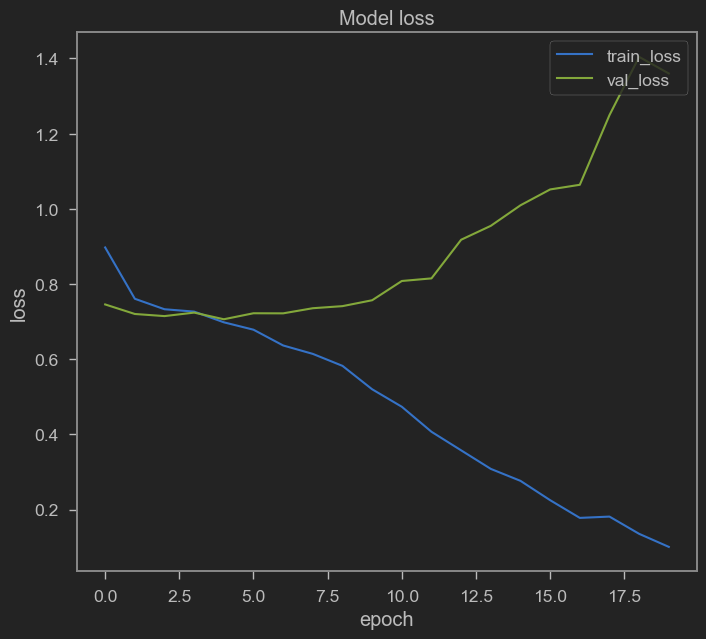

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss','val_loss'], loc = 'upper right')
plt.show()


InvalidArgumentError: Graph execution error:

Detected at node 'sequential/flatten_1/Reshape' defined at (most recent call last):
    File "c:\Users\jay4l\anaconda3\envs\py309\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "c:\Users\jay4l\anaconda3\envs\py309\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "c:\Users\jay4l\anaconda3\envs\py309\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "c:\Users\jay4l\anaconda3\envs\py309\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "c:\Users\jay4l\anaconda3\envs\py309\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "c:\Users\jay4l\anaconda3\envs\py309\lib\site-packages\tornado\platform\asyncio.py", line 205, in start
      self.asyncio_loop.run_forever()
    File "c:\Users\jay4l\anaconda3\envs\p